# Minimal continual-learning demo with Avalanche

This notebook implements the continual-learning loop directly with Avalanche's `SplitMNIST` benchmark and a PyTorch linear classifier.

The demo deliberately does **not** use any existing strategy from this repository. At each experience, the model trains only on that experience, then we evaluate it on all test experiences seen so far.

We track:
- **Accuracy:** average test accuracy over experiences seen so far.
- **Forgetting:** average drop, for previously learned experiences, from their best accuracy so far to their current accuracy.

The x-axis is the number of the newly completed experience.


In [89]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from avalanche.benchmarks.classic import SplitMNIST

SEED = 1
BATCH_SIZE = 128
EPOCHS_PER_EXPERIENCE = 1
LR = 0.01
N_SKILLS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [90]:
benchmark = SplitMNIST(
    n_experiences=10,
    seed=SEED,
)

train_stream = benchmark.train_stream
test_stream = benchmark.test_stream

print("Number of experiences:", len(train_stream))

for i, exp in enumerate(train_stream):
    print(i, sorted(exp.classes_in_this_experience), len(exp.dataset))


Number of experiences: 10
0 [5] 5421
1 [6] 5918
2 [1] 6742
3 [2] 5958
4 [0] 5923
5 [8] 5851
6 [9] 5949
7 [3] 6131
8 [7] 6265
9 [4] 5842


In [145]:
class LinearMNIST(nn.Module):
    def __init__(self, n_skills=10):
        super().__init__()

        self.skill_classifiers = nn.ModuleList(
            [nn.Linear(784, 10) for _ in range(n_skills)]
        )

        # Skill slots that have actually been learned.
        self.learned_skills = set()

        # Skill used by forward().
        self.active_skill = None

    def allocate_skill(self):
        for skill_index in range(len(self.skill_classifiers)):
            if skill_index not in self.learned_skills:
                self.learned_skills.add(skill_index)
                return skill_index

        raise RuntimeError("No free skill slots available.")

    def set_active_skill(self, skill_index):
        self.active_skill = skill_index

    def forward(self, x):
        x = x.flatten(start_dim=1)

        if self.active_skill is None:
            raise RuntimeError("No active skill selected.")

        return self.skill_classifiers[self.active_skill](x)


In [147]:
model = LinearMNIST(N_SKILLS).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
)


## Evaluation

After each training experience, evaluate the same model on every test experience.

This gives us an accuracy matrix:

`accuracy_history[t][j]`

where `t` is the current training experience and `j` is the test experience.


In [148]:
def evaluate_seen_experiences(strategy, current_experience):
    accuracies = []

    for experience_index in range(current_experience + 1):
        accuracy = strategy.evaluate_experience(
            test_stream[experience_index],
            experience_index,
        )

        accuracies.append(accuracy)

    return accuracies


## Continual-learning loop

The training loader contains **only the current experience**.

We do not replay previous training data and we do not use a continual-learning strategy.

After training experience `t`:
1. evaluate on test experiences `0 ... t`;
2. record the accuracy of each;
3. compute average accuracy over the experiences seen so far;
4. compute average forgetting over the previously seen experiences.


In [155]:
class MyStrategy:
    def __init__(self, model, optimizer, criterion):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion

    def find_best_skill(self, x, y):
        x = x.flatten(start_dim=1)
    
        best_skill = None
        best_loss = float("inf")
    
        for skill_index in self.model.learned_skills:
            classifier = self.model.skill_classifiers[skill_index]
    
            logits = classifier(x)
            loss = self.criterion(logits, y)
    
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_skill = skill_index
    
        return best_skill, best_loss
    
    
    def train_experience(self, train_exp):
        train_loader = DataLoader(
            train_exp.dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
        )
    
        # Get one batch to probe existing skills.
        x, y, _ = next(iter(train_loader))
    
        x = x.to(device)
        y = y.to(device)
    
        if not self.model.learned_skills:
            skill_index = self.model.allocate_skill()
    
            print(f"No existing skills -> allocated skill {skill_index}")
    
        else:
            skill_index, loss = self.find_best_skill(x, y)
    
            print(
                f"Best skill: {skill_index} "
                f"(probe loss = {loss:.4f})"
            )
    
        self.model.set_active_skill(skill_index)
    
        # Train using the selected skill.
        self.model.train()
    
        for epoch in range(EPOCHS_PER_EXPERIENCE):
            for x, y, _ in train_loader:
                x = x.to(device)
                y = y.to(device)
    
                self.optimizer.zero_grad()
    
                logits = self.model(x)
    
                loss = self.criterion(logits, y)
    
                loss.backward()
                self.optimizer.step()


    @torch.no_grad()
    def evaluate_experience(self, experience):
    
        self.model.eval()
    
        loader = DataLoader(
            experience.dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
        )
    
        correct = 0
        total = 0
    
        for x, y, _ in loader:
            x = x.to(device)
            y = y.to(device)
    
            skill_index, _ = self.find_best_skill(x, y)
    
            self.model.set_active_skill(skill_index)
    
            logits = self.model(x)
            predictions = logits.argmax(dim=1)
    
            correct += (predictions == y).sum().item()
            total += y.numel()
    
        return correct / total


In [156]:
strategy = MyStrategy(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
)

accuracy_history = []

for t, train_exp in enumerate(train_stream):

    strategy.train_experience(train_exp)

    current_accuracies = []

    for test_exp in test_stream[:t + 1]:
        accuracy = strategy.evaluate_experience(test_exp)
        current_accuracies.append(accuracy)

    accuracy_history.append(current_accuracies)

    print(
        f"Experience {t}: "
        f"trained on {sorted(train_exp.classes_in_this_experience)}, "
        f"mean seen accuracy = {np.mean(current_accuracies):.3f}"
    )


Best skill: 0 (probe loss = 0.0204)
Experience 0: trained on [5], mean seen accuracy = 1.000
Best skill: 0 (probe loss = 7.5980)
Experience 1: trained on [6], mean seen accuracy = 0.663
Best skill: 0 (probe loss = 4.9592)
Experience 2: trained on [1], mean seen accuracy = 0.686
Best skill: 0 (probe loss = 6.2800)
Experience 3: trained on [2], mean seen accuracy = 0.362
Best skill: 0 (probe loss = 6.4676)
Experience 4: trained on [0], mean seen accuracy = 0.456
Best skill: 0 (probe loss = 7.0501)
Experience 5: trained on [8], mean seen accuracy = 0.269
Best skill: 0 (probe loss = 7.0988)
Experience 6: trained on [9], mean seen accuracy = 0.227
Best skill: 0 (probe loss = 7.0708)
Experience 7: trained on [3], mean seen accuracy = 0.167
Best skill: 0 (probe loss = 6.7172)
Experience 8: trained on [7], mean seen accuracy = 0.208
Best skill: 0 (probe loss = 6.8043)
Experience 9: trained on [4], mean seen accuracy = 0.235


## Accuracy and catastrophic forgetting

For an earlier experience `j`, its forgetting at time `t` is:

`F(t,j) = max accuracy previously achieved on j - current accuracy on j`.

We report the mean forgetting over previously learned experiences.

The current experience is excluded from the forgetting average because it has not had an earlier opportunity to be forgotten.


In [157]:
n_experiences = len(train_stream)

accuracy_curve = []
forgetting_curve = []

for t in range(n_experiences):
    seen = np.asarray(accuracy_history[t], dtype=float)

    accuracy_curve.append(seen.mean())

    if t == 0:
        forgetting_curve.append(0.0)
        continue

    forgetting_values = []

    for j in range(t):
        past_accuracies = [
            accuracy_history[k][j]
            for k in range(j, t)
        ]

        best_accuracy = max(past_accuracies)
        current_accuracy = accuracy_history[t][j]

        forgetting_values.append(
            best_accuracy - current_accuracy
        )

    forgetting_curve.append(float(np.mean(forgetting_values)))

print("Accuracy:", np.round(accuracy_curve, 3))
print("Forgetting:", np.round(forgetting_curve, 3))


Accuracy: [1.    0.663 0.686 0.362 0.456 0.269 0.227 0.167 0.208 0.235]
Forgetting: [0.    0.672 0.469 0.849 0.679 0.877 0.902 0.952 0.89  0.849]


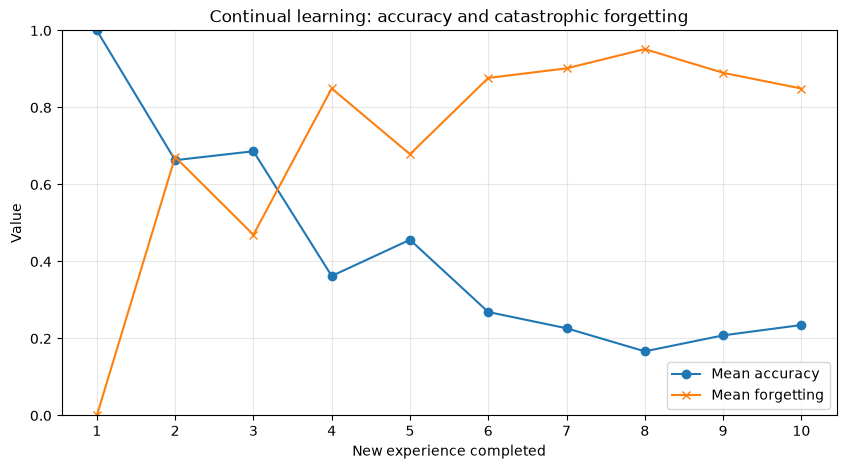

In [158]:
experiences = np.arange(1, n_experiences + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    experiences,
    accuracy_curve,
    marker="o",
    label="Mean accuracy",
)

plt.plot(
    experiences,
    forgetting_curve,
    marker="x",
    label="Mean forgetting",
)

plt.xlabel("New experience completed")
plt.ylabel("Value")
plt.title("Continual learning: accuracy and catastrophic forgetting")
plt.xticks(experiences)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.savefig("accuracy_forgetting_plot2.png", dpi=300, bbox_inches="tight")
plt.show()


## Per-experience accuracy over time

This second plot shows **where forgetting happens**.

Each line corresponds to one experience. After learning a new experience, the model is tested on all experiences learned so far.

A drop in an old experience's accuracy after a new experience is the visual signature of catastrophic forgetting.


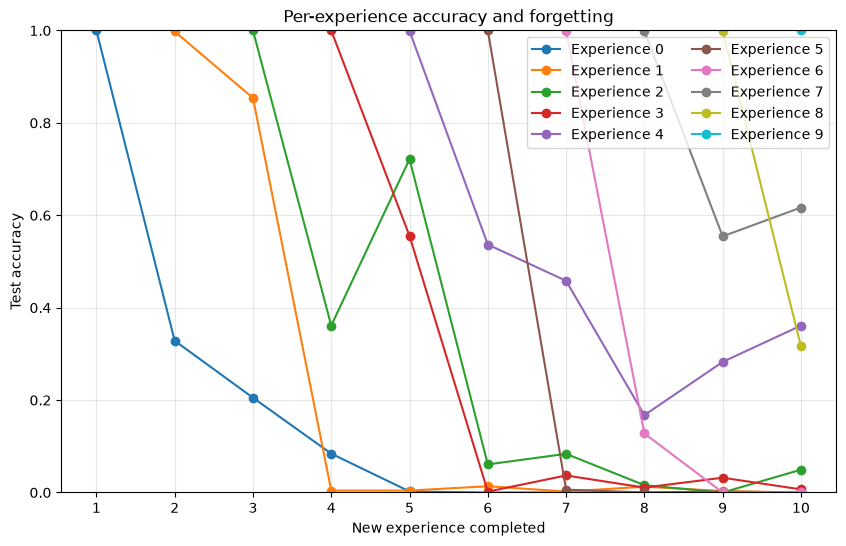

In [159]:
plt.figure(figsize=(10, 6))

for j in range(n_experiences):
    times = np.arange(j + 1, n_experiences + 1)
    values = [accuracy_history[t][j] for t in range(j, n_experiences)]

    plt.plot(
        times,
        values,
        marker="o",
        label=f"Experience {j}",
    )

plt.xlabel("New experience completed")
plt.ylabel("Test accuracy")
plt.title("Per-experience accuracy and forgetting")
plt.xticks(experiences)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.savefig("test_accuracy_trend_plot2.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This is intentionally a **baseline continual-learning demonstration**, not a strong benchmark.

The model sees one `SplitMNIST` experience at a time and receives no replay or memory. Because the experiences contain different digits, learning later experiences can change the shared linear classifier in ways that damage performance on earlier digits.

That degradation is what the forgetting curve measures.
